In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

In [3]:
det_frpm_crit_1404 = [210,252,294]
det_from_crit_1404 = np.array(det_frpm_crit_1404)
DW_exp_speed_1404 = [8.4,6.3,4.8]
DW_exp_speed_1404 = np.array(DW_exp_speed_1404)
fluct_decay_1404 = [4.,12.,13.0]
fluct_decay_1404 = np.array(fluct_decay_1404)
kn_1404 = 820 #Hz
det_norm_1404 = det_from_crit_1404/kn_1404
det_from_crit_1504 = [147,230]
det_from_crit_1504 = np.array(det_from_crit_1504)
DW_exp_speed_1504 = [21,7.5]
DW_exp_speed_1504 = np.array(DW_exp_speed_1504)
fluct_decay_1504 = [20.,3.5]
fluct_decay_1504 = np.array(fluct_decay_1504)
kn_1504 = 715 #Hz
det_norm_1504 = det_from_crit_1504/kn_1504

det_from_crit_1504_1 = [180]#,295,252]
det_from_crit_1504_1 = np.array(det_from_crit_1504_1)
DW_exp_speed_1504_1 = [15.2,]#7.6,9.9]
DW_exp_speed_1504_1 = np.array(DW_exp_speed_1504_1)
fluct_decay_1504_1 = [0.,]#0.]
fluct_decay_1504_1 = np.array(fluct_decay_1504_1)
kn_1504_1 = 735 #Hz
det_norm_1504_1 = det_from_crit_1504_1/kn_1504_1    

det_from_crit_all = np.concatenate((det_from_crit_1404, det_from_crit_1504))#, det_from_crit_1504_1))
DW_exp_speed_all = np.concatenate((DW_exp_speed_1404, DW_exp_speed_1504))#, DW_exp_speed_1504_1))
fluct_decay_all = np.concatenate((fluct_decay_1404, fluct_decay_1504))#, fluct_decay_1504_1))
det_norm_all = np.concatenate((det_norm_1404, det_norm_1504))#, det_norm_1504_1))


In [4]:
def fit_DW_speed(det_norm, alpha,A,B):
    speed = (np.abs(det_norm-0.5))**alpha*A + B
    
    return speed
    
def fit_DW_speed_1(det, delta_0,A,B):
    speed = A/(det-delta_0)+B
    
    return speed

In [5]:
fit_all_results = scipy.optimize.curve_fit(fit_DW_speed_1, det_from_crit_all, DW_exp_speed_all, p0=[0.5, 10.0, 0.0])
print(fit_all_results)

(array([1.04907425e+02, 8.70768112e+02, 3.08292427e-01]), array([[ 2.94171248e+01, -7.76403589e+02,  4.22197573e+00],
       [-7.76403589e+02,  2.07349109e+04, -1.14027053e+02],
       [ 4.22197573e+00, -1.14027053e+02,  6.44541041e-01]]))


In [6]:
fit_all_results = scipy.optimize.curve_fit(fit_DW_speed, det_norm_all, DW_exp_speed_all, p0=[1,10,0])
alpha_fit, A_fit, B_fit = fit_all_results[0]
print(f'Fitted alpha: {alpha_fit:.3f}, A: {A_fit:.3f}, B: {B_fit:.3f}')

Fitted alpha: 9.389, A: 1449881.587, B: 6.007


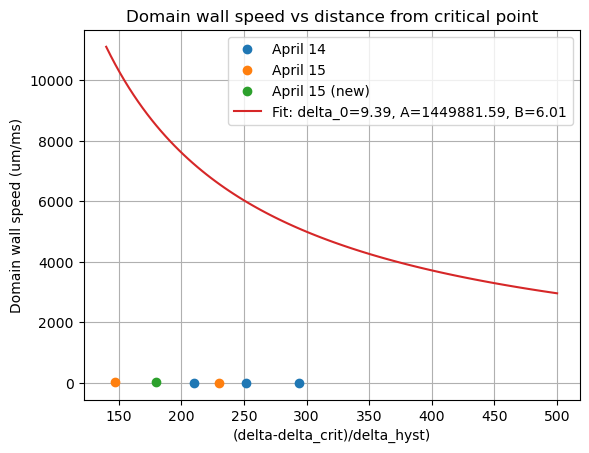

In [7]:
plt.figure()
plt.plot(det_from_crit_1404,DW_exp_speed_1404,'o', label='April 14')
plt.plot(det_from_crit_1504,DW_exp_speed_1504,'o', label='April 15')
plt.plot(det_from_crit_1504_1,DW_exp_speed_1504_1,'o', label='April 15 (new)')
det_from_crit_all_for_fit = np.linspace(140,500,100)
plt.plot(det_from_crit_all_for_fit, fit_DW_speed_1(det_from_crit_all_for_fit, *fit_all_results[0]), '-', label=f'Fit: delta_0={fit_all_results[0][0]:.2f}, A={fit_all_results[0][1]:.2f}, B={fit_all_results[0][2]:.2f}')

#plt.plot(det_norm_all_for_fit, fit_DW_speed(det_norm_all_for_fit, *fit_all_results[0]), '-', label=f'Fit: alpha={alpha_fit:.2f}, A={A_fit:.2f}')
plt.xlabel('(delta-delta_crit)/delta_hyst)')
plt.ylabel('Domain wall speed (um/ms)')
plt.title('Domain wall speed vs distance from critical point')
plt.grid()
plt.legend()
plt.show()

In [8]:
plt.figure()
plt.plot(det_from_crit,fluct_decay,'o')
plt.xlabel('Distance from critical point (Hz)')
plt.ylabel('Fluctuation decay time (ms)')
plt.title('Fluctuation decay time vs distance from critical point')
plt.grid()
plt.show()

NameError: name 'det_from_crit' is not defined

<Figure size 640x480 with 0 Axes>

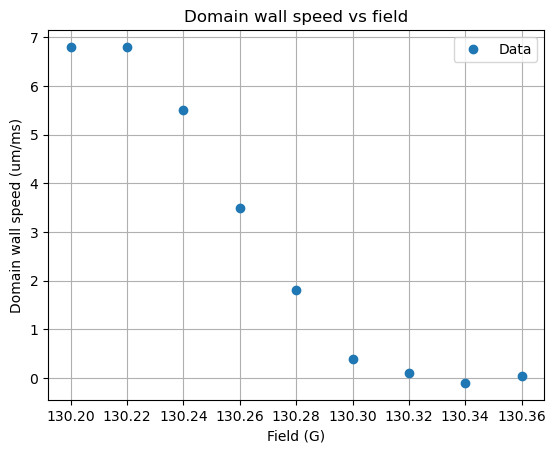

In [10]:
fields = [130.2,130.22,130.24,130.26,130.28,130.3,130.32,130.34,130.36]
speeds = [6.8,6.8,5.5,3.5,1.8,0.4,0.1,-0.1,0.05]
fields = np.array(fields)
speeds = np.array(speeds)
#fit_results = scipy.optimize.curve_fit(fit_DW_speed_1, fields, speeds, p0=[130.3, 10.0, 0.0])
#print(fit_results)
plt.figure()
plt.plot(fields, speeds, 'o', label='Data')
fields_for_fit = np.linspace(130.2,130.36,100)
#plt.plot(fields_for_fit, fit_DW_speed_1(fields_for_fit, *fit_results[0]), '-', label=f'Fit: delta_0={fit_results[0][0]:.2f}, A={fit_results[0][1]:.2f}, B={fit_results[0][2]:.2f}')
plt.xlabel('Field (G)')
plt.ylabel('Domain wall speed (um/ms)')
plt.title('Domain wall speed vs field')
plt.grid()
plt.legend()
plt.show()